In [12]:
from IPython.display import display, HTML
display(HTML('<a href="https://rlukkoor.github.io/Geospatial-Projects/Project%205%20-%20Vulnerability/vulnerability_map.html" target="_blank">Click here to view the interactive vulnerability map</a>'))

In [1]:
# ── Cell 1: imports ───────────────────────────────────────────────────────────
%matplotlib inline
%pip install folium

import io
import os
import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.features
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import osmnx as ox
import folium
from shapely.geometry import shape, mapping
from rasterio.windows import from_bounds
from rasterio.transform import Affine

warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Cell 2: load municipality boundaries ─────────────────────────────────────
muni_url = "https://cartomap.github.io/nl/wgs84/gemeente_2023.geojson"
response = requests.get(muni_url, verify=False, timeout=60)
municipalities = gpd.read_file(io.BytesIO(response.content))
municipalities = municipalities[["statnaam", "geometry"]].rename(
    columns={"statnaam": "name"}
)
municipalities["geometry"] = municipalities.geometry.buffer(0)
municipalities = municipalities.to_crs("EPSG:28992")
municipalities["area_m2"]  = municipalities.geometry.area
print(f"Municipalities loaded: {len(municipalities)}")

Municipalities loaded: 342


In [3]:
# ── Cell 2b: deduplicate municipalities ───────────────────────────────────────
municipalities = municipalities.drop_duplicates(subset="name").reset_index(drop=True)
print(f"Municipalities after dedup: {len(municipalities)}")

Municipalities after dedup: 342


In [4]:
# ── Cell 3: flood risk score from SRTM ───────────────────────────────────────
import zipfile

# Download SRTM tile if not already present
dem_zip_url = (
    "https://srtm.csi.cgiar.org/wp-content/uploads/files/"
    "srtm_5x5/TIFF/srtm_38_02.zip"
)
dem_path = "srtm_38_02.tif"

if not os.path.exists(dem_path):
    print("Downloading SRTM tile (~25MB)...")
    r = requests.get(dem_zip_url, verify=False, timeout=120, stream=True)
    with open("srtm_38_02.zip", "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("srtm_38_02.zip", "r") as z:
        tif_names = [n for n in z.namelist() if n.endswith(".tif")]
        z.extract(tif_names[0], ".")
        dem_path = tif_names[0]
    print(f"DEM ready: {dem_path}")
else:
    print(f"DEM already exists: {dem_path}")

# Load raster and reproject municipalities to match
with rasterio.open(dem_path) as src:
    raster_crs = src.crs
    nodata     = src.nodata
    elevation  = src.read(1).astype(float)
    transform  = src.transform

muni_4326 = municipalities.to_crs(raster_crs)
muni_4326["geometry"] = muni_4326.geometry.buffer(0)

# Classify high risk pixels (0–2m above sea level)
elevation[elevation == nodata] = np.nan
high_risk = np.where(
    (elevation >= 0) & (elevation <= 2), 1, 0
).astype(np.uint8)

# Vectorise high-risk pixels into polygons
risk_shapes = [
    shape(geom)
    for geom, val in rasterio.features.shapes(high_risk, transform=transform)
    if val == 1
]
risk_gdf = gpd.GeoDataFrame(geometry=risk_shapes, crs=raster_crs)
risk_gdf = risk_gdf.to_crs("EPSG:28992")

# Overlay with municipalities to get high-risk area per municipality
risk_intersection = gpd.overlay(
    risk_gdf[["geometry"]],
    municipalities[["name", "geometry", "area_m2"]],
    how="intersection",
)
risk_intersection["risk_area"] = risk_intersection.geometry.area

risk_by_muni = (
    risk_intersection.groupby("name")["risk_area"]
    .sum()
    .reset_index()
)

municipalities = municipalities.merge(risk_by_muni, on="name", how="left")
municipalities["risk_area"]      = municipalities["risk_area"].fillna(0)
municipalities["flood_risk_pct"] = (
    municipalities["risk_area"] / municipalities["area_m2"] * 100
).clip(upper=100)

print("Flood risk scores computed")
print(
    municipalities[["name", "flood_risk_pct"]]
    .sort_values("flood_risk_pct", ascending=False)
    .head(5)
    .to_string(index=False)
)

DEM ready: srtm_38_02.tif
Flood risk scores computed
      name  flood_risk_pct
Zaltbommel       67.872504
    Houten       66.696882
    Bunnik       63.668069
   Veendam       62.243110
 Culemborg       59.354181


In [5]:
# ── Cell 4: green space score via CBS land use data ───────────────────────────
green_url = (
    "https://opendata.cbs.nl/ODataApi/odata/70262ned/TypedDataSet"
    "?$format=json"
    "&$filter=startswith(RegioS,'GM') and Perioden eq '2017JJ00'"
    "&$select=RegioS,ParkEnPlantsoen_20"
)
response   = requests.get(green_url, verify=False, timeout=60)
green_data = response.json().get("value", [])
green_df   = pd.DataFrame(green_data)
green_df["RegioS"]        = green_df["RegioS"].str.strip()
green_df["green_area_ha"] = pd.to_numeric(
    green_df["ParkEnPlantsoen_20"], errors="coerce"
).fillna(0)

# Reload code lookup
code_url    = "https://cartomap.github.io/nl/wgs84/gemeente_2023.geojson"
response    = requests.get(code_url, verify=False, timeout=60)
code_lookup = gpd.read_file(io.BytesIO(response.content))
code_lookup = code_lookup[["statcode", "statnaam"]].copy()
code_lookup.columns = ["gm_code", "muni_name"]
code_lookup["gm_code"] = code_lookup["gm_code"].str.strip()

# Merge and deduplicate — keep one row per municipality
green_df = green_df.merge(
    code_lookup, left_on="RegioS", right_on="gm_code", how="left"
)
green_df = green_df.dropna(subset=["muni_name"])
green_df = (
    green_df.groupby("muni_name")["green_area_ha"]
    .mean()  # average if multiple matches
    .reset_index()
    .rename(columns={"muni_name": "name"})
)
print(f"Unique municipalities with green space data: {len(green_df)}")

# Drop green columns if they already exist from a previous run
for col in ["green_area_ha", "green_space_pct"]:
    if col in municipalities.columns:
        municipalities = municipalities.drop(columns=[col])

municipalities = municipalities.merge(green_df, on="name", how="left")
municipalities["green_area_ha"]   = municipalities["green_area_ha"].fillna(0)
municipalities["green_space_pct"] = (
    municipalities["green_area_ha"] * 10000
    / municipalities["area_m2"] * 100
).clip(upper=100)

print("\nGreen space scores computed")
print(
    municipalities[["name", "green_space_pct"]]
    .sort_values("green_space_pct", ascending=False)
    .head(5)
    .to_string(index=False)
)

Unique municipalities with green space data: 325

Green space scores computed
                  name  green_space_pct
              Rijswijk        17.027075
Capelle aan den IJssel        11.836875
            Zoetermeer        10.748820
            Nieuwegein        10.276942
                 Delft         9.849111


In [6]:
# ── Cell 5: population density from WorldPop raster ──────────────────────────
# WorldPop 1km population density raster for Netherlands, 2020
pop_url  = (
    "https://data.worldpop.org/GIS/Population_Density/Global_2000_2020_1km/"
    "2020/NLD/nld_pd_2020_1km.tif"
)
pop_path = "nld_population_density.tif"

if not os.path.exists(pop_path):
    print("Downloading WorldPop population density raster...")
    r = requests.get(pop_url, verify=False, stream=True, timeout=120)
    r.raise_for_status()
    total      = int(r.headers.get("content-length", 0))
    downloaded = 0
    with open(pop_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 512):
            f.write(chunk)
            downloaded += len(chunk)
            if total:
                print(f"  {downloaded/1e6:.1f} / {total/1e6:.1f} MB", end="\r")
    print(f"\n  Done: {pop_path}")
else:
    print(f"Already exists: {pop_path}")

# Compute mean population density per municipality using zonal statistics
with rasterio.open(pop_path) as src:
    pop_crs = src.crs
    muni_pop_crs = municipalities.to_crs(pop_crs)

    pop_density_list = []
    for _, row in muni_pop_crs.iterrows():
        try:
            masked, _ = rasterio.mask.mask(
                src, [mapping(row.geometry)], crop=True, nodata=np.nan
            )
            data = masked[0].astype(float)
            data[data <= 0] = np.nan
            mean_density = np.nanmean(data) if not np.all(np.isnan(data)) else 0
        except Exception:
            mean_density = 0
        pop_density_list.append(mean_density)

municipalities["pop_density"] = pop_density_list

print("\nPopulation density computed")
print(
    municipalities[["name", "pop_density"]]
    .sort_values("pop_density", ascending=False)
    .head(5)
    .to_string(index=False)
)

  0.3 / 0.3 MB
  Done: nld_population_density.tif

Population density computed
                  name  pop_density
         's-Gravenhage  6022.651099
                Leiden  4969.958873
               Haarlem  4773.745268
                 Delft  4173.469411
Capelle aan den IJssel  4089.977905


In [7]:
# ── Cell 6: normalise indicators to 0–1 scale ────────────────────────────────
def minmax(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx > mn else series * 0

municipalities["flood_norm"]   = minmax(municipalities["flood_risk_pct"])
municipalities["green_norm"]   = minmax(municipalities["green_space_pct"])
municipalities["pop_norm"]     = minmax(municipalities["pop_density"])

print("Normalised ranges:")
for col in ["flood_norm", "green_norm", "pop_norm"]:
    print(f"  {col}: {municipalities[col].min():.2f} – {municipalities[col].max():.2f}")

Normalised ranges:
  flood_norm: 0.00 – 1.00
  green_norm: 0.00 – 1.00
  pop_norm: 0.00 – 1.00


In [8]:
# ── Cell 7: compute composite vulnerability index ────────────────────────────
# Weights: flood risk 40%, population density 35%, green space deficit 25%
# High flood risk → more vulnerable
# High population density → more vulnerable
# High green space → less vulnerable (so we subtract)
W_FLOOD = 0.40
W_POP   = 0.35
W_GREEN = 0.25

municipalities["vulnerability"] = (
    W_FLOOD * municipalities["flood_norm"] +
    W_POP   * municipalities["pop_norm"] +
    W_GREEN * (1 - municipalities["green_norm"])  # invert: less green = more vulnerable
)

# Normalise final score to 0–100
municipalities["vulnerability"] = minmax(municipalities["vulnerability"]) * 100

print("\nTop 10 most vulnerable municipalities:")
print(
    municipalities[["name", "flood_risk_pct", "green_space_pct", "pop_density", "vulnerability"]]
    .sort_values("vulnerability", ascending=False)
    .head(10)
    .to_string(index=False)
)


Top 10 most vulnerable municipalities:
       name  flood_risk_pct  green_space_pct  pop_density  vulnerability
     Houten       66.696882         1.589215  1102.063641     100.000000
 Zaltbommel       67.872504         0.544256   315.303544      95.357033
IJsselstein       54.313488         1.700134  1690.373351      92.075312
     Bunnik       63.668069         0.486352   434.487511      92.018491
  Culemborg       59.354181         1.976923   960.833769      88.751588
    Veendam       62.243110         1.848427   356.074526      85.535294
West Betuwe       56.887951         0.000000   230.262088      83.223226
    Ameland       57.080954         0.036936    59.377655      81.380587
     Pekela       56.477302         0.672012   255.293347      81.094141
    Utrecht       37.413091         6.904402  3640.329804      79.825415


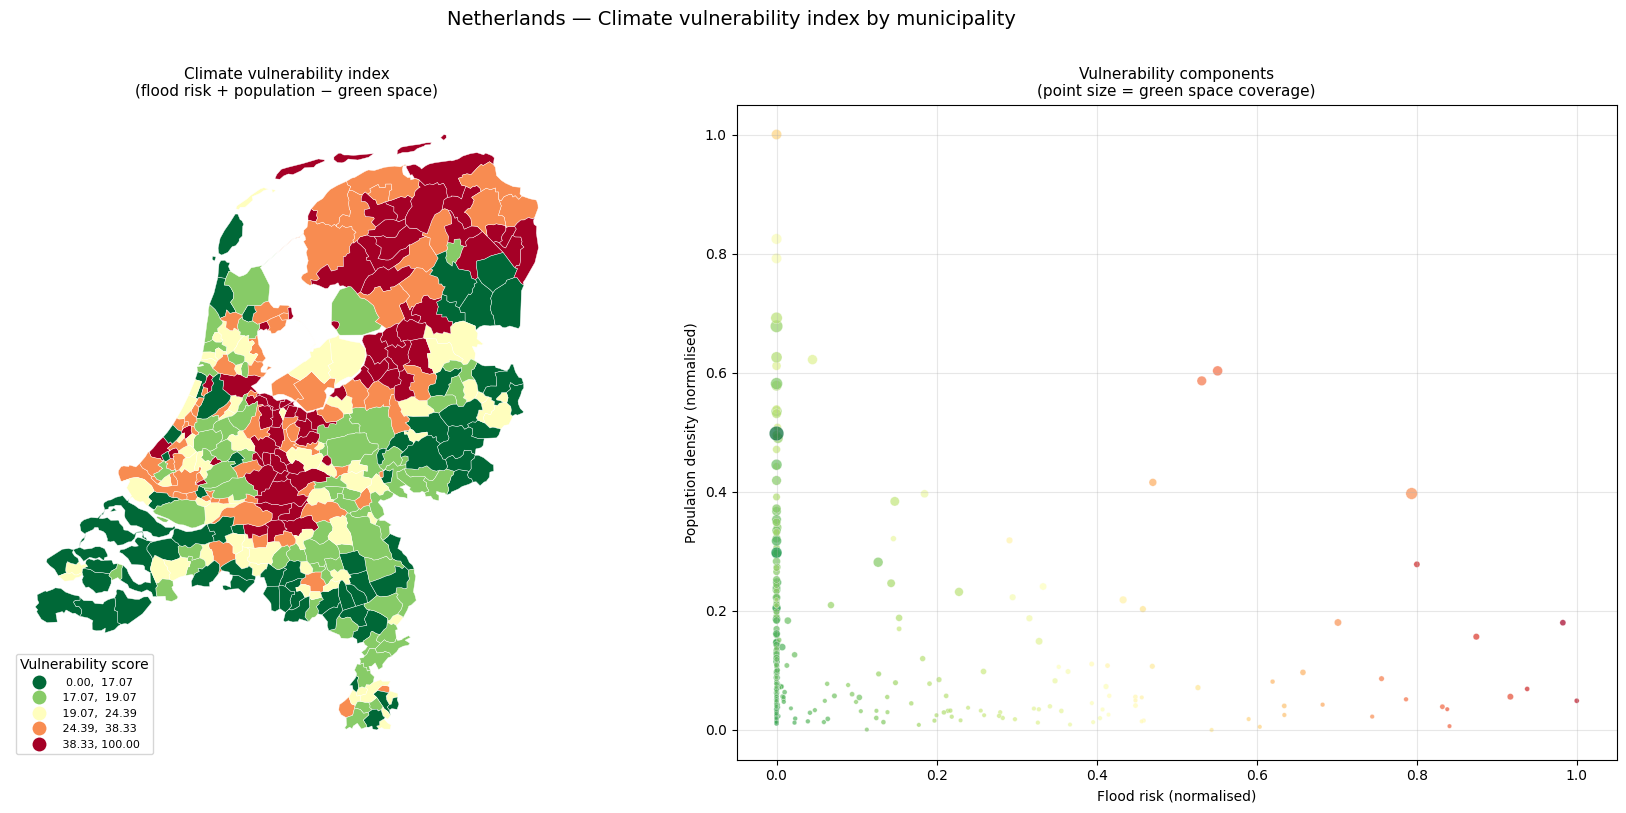

In [9]:
# ── Cell 8: choropleth — vulnerability index ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left — composite vulnerability
municipalities.plot(
    column="vulnerability", ax=axes[0], cmap="RdYlGn_r",
    scheme="quantiles", k=5, legend=True,
    legend_kwds={"title": "Vulnerability score", "loc": "lower left", "fontsize": 8},
    edgecolor="white", linewidth=0.3,
    missing_kwds={"color": "#eeeeee"},
)
axes[0].set_title("Climate vulnerability index\n(flood risk + population − green space)",
                  fontsize=11)
axes[0].set_axis_off()

# Right — component breakdown as scatter
axes[1].scatter(
    municipalities["flood_norm"],
    municipalities["pop_norm"],
    c=municipalities["vulnerability"],
    s=municipalities["green_norm"] * 100 + 10,
    cmap="RdYlGn_r", alpha=0.7, edgecolors="white", linewidths=0.3,
)
axes[1].set_xlabel("Flood risk (normalised)", fontsize=10)
axes[1].set_ylabel("Population density (normalised)", fontsize=10)
axes[1].set_title("Vulnerability components\n(point size = green space coverage)",
                  fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Netherlands — Climate vulnerability index by municipality",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.close()

In [10]:
# ── Cell 9: ranked summary table ─────────────────────────────────────────────
summary = municipalities[[
    "name", "flood_risk_pct", "green_space_pct", "pop_density", "vulnerability"
]].copy()
summary["flood_risk_pct"]  = summary["flood_risk_pct"].round(1)
summary["green_space_pct"] = summary["green_space_pct"].round(1)
summary["pop_density"]     = summary["pop_density"].round(0).astype(int)
summary["vulnerability"]   = summary["vulnerability"].round(1)
summary = summary.sort_values("vulnerability", ascending=False).reset_index(drop=True)
summary.index += 1
print(summary.head(20).to_string())

             name  flood_risk_pct  green_space_pct  pop_density  vulnerability
1          Houten            66.7              1.6         1102          100.0
2      Zaltbommel            67.9              0.5          315           95.4
3     IJsselstein            54.3              1.7         1690           92.1
4          Bunnik            63.7              0.5          434           92.0
5       Culemborg            59.4              2.0          961           88.8
6         Veendam            62.2              1.8          356           85.5
7     West Betuwe            56.9              0.0          230           83.2
8         Ameland            57.1              0.0           59           81.4
9          Pekela            56.5              0.7          255           81.1
10        Utrecht            37.4              6.9         3640           79.8
11      Maasdriel            53.4              0.2          330           79.7
12          Hoorn            36.1              6.3  

In [11]:
# ── Cell 10: interactive Folium map ──────────────────────────────────────────
# Reproject to WGS84 for Folium
muni_wgs = municipalities.to_crs("EPSG:4326")

# Compute map centre
centre = [muni_wgs.geometry.centroid.y.mean(), muni_wgs.geometry.centroid.x.mean()]
m = folium.Map(location=centre, zoom_start=7, tiles="CartoDB positron")

# Choropleth layer
folium.Choropleth(
    geo_data=muni_wgs.__geo_interface__,
    data=municipalities[["name", "vulnerability"]],
    columns=["name", "vulnerability"],
    key_on="feature.properties.name",
    fill_color="RdYlGn_r",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Climate vulnerability index (0–100)",
    nan_fill_color="lightgrey",
).add_to(m)

# Tooltip layer with all indicator values
tooltip_gdf = muni_wgs[["name", "flood_risk_pct", "green_space_pct",
                          "pop_density", "vulnerability", "geometry"]].copy()
tooltip_gdf["flood_risk_pct"]  = tooltip_gdf["flood_risk_pct"].round(1)
tooltip_gdf["green_space_pct"] = tooltip_gdf["green_space_pct"].round(1)
tooltip_gdf["pop_density"]     = tooltip_gdf["pop_density"].round(0)
tooltip_gdf["vulnerability"]   = tooltip_gdf["vulnerability"].round(1)

folium.GeoJson(
    tooltip_gdf,
    style_function=lambda x: {
        "fillOpacity": 0, "weight": 0.5, "color": "white"
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "vulnerability", "flood_risk_pct",
                "green_space_pct", "pop_density"],
        aliases=["Municipality", "Vulnerability score", "Flood risk %",
                 "Green space %", "Pop density (per km²)"],
        localize=True,
    ),
).add_to(m)

m.save("vulnerability_map.html")
print("Interactive map saved: vulnerability_map.html")
display(m)

Interactive map saved: vulnerability_map.html
